In [ ]:
%load_ext autoreload
%autoreload 2

## Basics

In [2]:
import numpy as np
import torch
import scanpy as sc
import matplotlib.pyplot as plt
import functools
import pandas as pd
import ot as pot
import warnings
import os
import dcor

from sc_flow import SCFlow
from sc_flow.backends.torch.coupling import ot_linear_coupling
from sc_flow.data.samplers._train import MultiTransitionSampler
from sc_flow.backends.torch.metrics import MaximumMeanDiscrepancy
from sc_flow.backends.torch.probability_paths import LinearGaussianProbabilityPath

SEED = 44
np.random.seed(SEED)
torch.manual_seed(SEED)
prng = torch.Generator().manual_seed(SEED)
warnings.filterwarnings("ignore")

In [3]:
DATA_PATH = "400_data\\GSE232025_stereoseq_g_10000_nzp_0.1.h5ad"
STAGES_ALL = ["Stage44", "Stage54", "Stage57", "Juvenile", "Adult"]
STAGE_TIMES = {"Stage44": 0, "Stage54": 1, "Stage57": 2, "Juvenile": 3, "Adult": 4}

In [4]:
adata = sc.read_h5ad(DATA_PATH)

X_pca = adata.obsm["X_pca"].astype(np.float32)
ss_context = adata.obsm["local_mean_X_pca"].astype(np.float32)
lr_pattern = adata.obsm["LR_pattern"].astype(np.float32)

adata.obsm["X_state_ctx"] = np.concatenate([X_pca, ss_context, lr_pattern], axis=1)
adata.uns["stage_emb"] = {s: np.array([t], dtype=np.float32) for s, t in STAGE_TIMES.items()}
adata.obs["day"] = adata.obs["day"].astype(int).map(dict(enumerate(STAGES_ALL)))
print(f"X_pca shape:        {X_pca.shape}")
print(f"ss_context shape:   {ss_context.shape}")
print(f"lr_pattern shape:   {lr_pattern.shape}")
print(f"X_state_ctx shape:  {adata.obsm['X_state_ctx'].shape}")

X_pca shape:        (28757, 50)
ss_context shape:   (28757, 50)
lr_pattern shape:   (28757, 233)
X_state_ctx shape:  (28757, 333)


In [5]:
from sc_flow.backends.torch.coupling._coupling import configure_ot_debug
from sc_flow.backends.torch.coupling._coupling import _OT_DEBUG

# Functions

In [6]:
def ctf_c_coupling(source_lin, target_lin, CTF_LAMBDA, CTF_ALPHA, N_PCA, N_SS, scale_method, reg, **kwargs):
    """CTF-C: ot_linear_coupling with spatially-biased cost (SS + LR TPM)."""
    src_pca = source_lin[:, :N_PCA]
    src_ss = source_lin[:, N_PCA : N_PCA + N_SS]
    src_lr = source_lin[:, N_PCA + N_SS :]

    tgt_pca = target_lin[:, :N_PCA]
    tgt_ss = target_lin[:, N_PCA : N_PCA + N_SS]
    tgt_lr = target_lin[:, N_PCA + N_SS :]

    def cost_fn(src, tgt):
        """Build spatially-blended OT cost from PCA, SS, and LR distances."""
        C_pca = torch.cdist(src, tgt) ** 2
        C_pca = C_pca / C_pca.max()

        SS = torch.cdist(src_ss, tgt_ss) ** 2
        SS = SS / SS.max()

        LR = torch.cdist(src_lr, tgt_lr) ** 2
        LR = LR / LR.max()

        M = CTF_ALPHA * SS + (1 - CTF_ALPHA) * LR
        cost = CTF_LAMBDA * C_pca + (1 - CTF_LAMBDA) * M
        return cost

    result = ot_linear_coupling(src_pca, tgt_pca, cost_fn=cost_fn, scale_cost=scale_method, reg=reg)

    return result

In [ ]:
def ctf_c_coupling(source_lin, target_lin, CTF_LAMBDA, CTF_ALPHA, N_PCA, N_SS, scale_method, reg, **kwargs):  # noqa: F811
    """CTF-C: ot_linear_coupling with spatially-biased cost (SS + LR TPM)."""
    src_pca = source_lin[:, :N_PCA]
    src_ss = source_lin[:, N_PCA : N_PCA + N_SS]
    src_lr = source_lin[:, N_PCA + N_SS :]

    tgt_pca = target_lin[:, :N_PCA]
    tgt_ss = target_lin[:, N_PCA : N_PCA + N_SS]
    tgt_lr = target_lin[:, N_PCA + N_SS :]

    cost_components = {}

    def cost_fn(src, tgt):
        """Build spatially-blended OT cost from PCA, SS, and LR distances."""
        C_pca = torch.cdist(src, tgt) ** 2
        C_pca = C_pca / C_pca.max()

        SS = torch.cdist(src_ss, tgt_ss) ** 2
        SS = SS / SS.max()

        LR = torch.cdist(src_lr, tgt_lr) ** 2
        LR = LR / LR.max()

        M = CTF_ALPHA * SS + (1 - CTF_ALPHA) * LR
        cost = CTF_LAMBDA * C_pca + (1 - CTF_LAMBDA) * M

        cost_components["C_pca"] = C_pca
        cost_components["SS"] = SS
        cost_components["LR"] = LR
        cost_components["M"] = M
        cost_components["cost"] = cost
        return cost

    result = ot_linear_coupling(src_pca, tgt_pca, cost_fn=cost_fn, scale_cost=scale_method, reg=reg)

    if _OT_DEBUG["enabled"] and _OT_DEBUG["_step"] <= _OT_DEBUG["max_steps"]:
        step_dir = os.path.join(_OT_DEBUG["output_dir"], f"step_{_OT_DEBUG['_step']:04d}")
        np.savez_compressed(
            os.path.join(step_dir, f"transition_{_OT_DEBUG['_transition']}_cost_inputs.npz"),
            src_ss=src_ss.detach().cpu().numpy(),
            src_lr=src_lr.detach().cpu().numpy(),
            tgt_ss=tgt_ss.detach().cpu().numpy(),
            tgt_lr=tgt_lr.detach().cpu().numpy(),
            **{k: v.detach().cpu().numpy() for k, v in cost_components.items()},
        )

    return result

In [8]:
def run(
    MATCHED_KEYS,
    LAMBDA,
    ALPHA,
    scale_method,
    reg,
    hidden_dims,
    activation,
    epoch,
    batch_size,
    lr,
    probability_path,
    encode_state,
    encode_time,
):
    """Run model"""
    SCFlow.register_adata(
        adata,
        sample_rep="X_pca",
        coupling_rep="X_state_ctx",
        conditions={"day": ["day"]},
        conditions_reps={"day": "stage_emb"},
        matched_keys=MATCHED_KEYS,
    )

    ctf_c_partial = functools.partial(
        ctf_c_coupling,
        CTF_LAMBDA=LAMBDA,
        CTF_ALPHA=ALPHA,
        N_PCA=50,
        N_SS=50,
        scale_method=scale_method,
        reg=reg,
    )

    model = SCFlow(
        method_id="cfm",
        backend="torch",
        match_fn=ctf_c_partial,
        vf_decoder_mlp_kwargs={"hidden_dims": hidden_dims, "activation_cls": activation},
        encode_state=encode_state,
        encode_time=encode_time,
        probability_path=probability_path,
    )

    model.train(
        adata,
        callbacks=None,
        sort=True,
        n_train_steps=epoch,
        train_batch_size=batch_size,
        train_sampler=MultiTransitionSampler,
        optim_kwargs={"lr": lr},
        timepoints=[0, 1, 2, 3],
    )

    return model

In [9]:
def predict(model, solver, PRED_KEYS, T_START_PRED, T_END_PRED):
    """Predict with trained model"""
    preds_extra = {}
    for (src, tgt), ts, te in zip(PRED_KEYS, T_START_PRED, T_END_PRED, strict=False):
        result = model.predict(
            adata,
            solver_kwargs={"method": solver},
            sort=True,
            matched_keys={(src,): (tgt,)},
            return_trajectory=True,
            num_steps=400,
            t_start=ts,
            t_end=te,
        )
        preds_extra[(src, tgt)] = np.array(result.X)

    return preds_extra

In [10]:
def predict_ivp(model, transitions_ordered, t_start=0.0, t_end=4.0, num_steps=401):
    """Single ODE solve from t_start to t_end; slices trajectory at each integer transition boundary."""
    transitions_ordered = list(transitions_ordered)
    src_stage = transitions_ordered[0][0]
    tgt_stage = transitions_ordered[-1][1]

    result = model.predict(
        adata,
        sort=True,
        matched_keys={(src_stage,): (tgt_stage,)},
        return_trajectory=True,
        num_steps=num_steps,
        t_start=t_start,
        t_end=t_end,
    )

    # result.obsm["trajectory"]: (n_cells, num_steps, features)
    traj = result.obsm["trajectory"]

    preds = {}
    for i, (src, tgt) in enumerate(transitions_ordered):
        t_boundary = t_start + i + 1
        idx = round((t_boundary - t_start) / (t_end - t_start) * (num_steps - 1))
        preds[(src, tgt)] = traj[:, idx, :]

    return preds

In [ ]:
# def compute_w2(X, Y):
#     """Compute 2-Wasserstein distance between X and Y."""
#     rng = np.random.RandomState(SEED)
#     Xi = X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)].astype(np.float64)
#     Yi = Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)].astype(np.float64)
#     a, b = pot.unif(Xi.shape[0]), pot.unif(Yi.shape[0])
#     M = torch.cdist(torch.tensor(Xi).float(), torch.tensor(Yi).float()).numpy().astype(np.float64) ** 2
#     return float(np.sqrt(pot.emd2(a, b, M)))


def compute_w2(X, Y):
    """Compute sliced 2-Wasserstein distance between X and Y."""
    rng = np.random.RandomState(SEED)
    Xi = X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)].astype(np.float64)
    Yi = Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)].astype(np.float64)
    return float(pot.sliced.sliced_wasserstein_distance(Xi, Yi, n_projections=200, p=2, seed=SEED))


def compute_mmd(X, Y):
    """Compute MMD between X and Y."""
    rng = np.random.RandomState(SEED)
    Xi = torch.tensor(X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]).float()
    Yi = torch.tensor(Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]).float()
    m = MaximumMeanDiscrepancy()
    m.update(Xi, Yi)
    return float(m.compute())


def compute_energy(X, Y):
    """Compute energy distance between X and Y (unbiased, matches contextflow)."""
    rng = np.random.RandomState(SEED)
    Xi = X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]
    Yi = Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]
    return float(dcor.energy_distance(Xi, Yi))


def compute_metrics(preds_extra, adata):
    """Compute all metrics and plot a line graph of model (solid) vs baseline (dashed)."""
    rows = []
    ordered_keys = sorted(preds_extra.keys(), key=lambda x: STAGES_ALL.index(x[0]))
    for src, tgt in ordered_keys:
        pred = preds_extra[(src, tgt)]
        true_tgt = adata[adata.obs["day"] == tgt].obsm["X_pca"].astype(np.float32)
        src_cells = adata[adata.obs["day"] == src].obsm["X_pca"].astype(np.float32)

        rows.append(
            {
                "transition": f"{src} -> {tgt}",
                "W2 (model)": compute_w2(pred, true_tgt),
                "W2 (baseline)": compute_w2(src_cells, true_tgt),
                "MMD (model)": compute_mmd(pred, true_tgt),
                "MMD (baseline)": compute_mmd(src_cells, true_tgt),
                "Energy (model)": compute_energy(pred, true_tgt),
                "Energy (baseline)": compute_energy(src_cells, true_tgt),
            }
        )

    df = pd.DataFrame(rows).set_index("transition").round(4)

    metrics = [("W2", "#1f77b4"), ("MMD", "#ff7f0e"), ("Energy", "#2ca02c")]
    x = np.arange(len(df))
    x_labels = df.index.tolist()

    fig, ax = plt.subplots(figsize=(10, 4))
    for name, color in metrics:
        ax.plot(
            x, df[f"{name} (model)"].values, color=color, linestyle="-", linewidth=2, marker="o", label=f"{name} model"
        )
        ax.plot(
            x,
            df[f"{name} (baseline)"].values,
            color=color,
            linestyle="--",
            linewidth=1.5,
            marker="o",
            label=f"{name} baseline",
        )
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=15, ha="right")
    ax.set_ylabel("Metric value")
    ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    return df

In [12]:
def plot_transitions(adata, transitions, preds_dict, title=None):
    """Plot each transition in a separate subplot."""
    fig, axes = plt.subplots(1, len(transitions), figsize=(6 * len(transitions), 5))
    if len(transitions) == 1:
        axes = [axes]

    X_pca_all = adata.obsm["X_pca"]
    for ax, (src, tgt) in zip(axes, transitions, strict=False):
        src_mask = adata.obs["day"].values == src
        tgt_mask = adata.obs["day"].values == tgt
        X_pred = preds_dict[(src, tgt)]

        ax.scatter(X_pca_all[src_mask, 0], X_pca_all[src_mask, 1], s=2, alpha=0.15, color="steelblue", label=src)
        ax.scatter(X_pred[:, 0], X_pred[:, 1], s=5, alpha=0.7, color="tomato", label="Predicted")
        ax.scatter(X_pca_all[tgt_mask, 0], X_pca_all[tgt_mask, 1], s=2, alpha=0.5, color="seagreen", label=tgt)
        ax.set_title(f"{src} → {tgt}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(loc="upper right", markerscale=2, frameon=False)

    if title:
        plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

# Runs

## Extrapolation

In [13]:
# print model.method.module
ALPHA = 0.5
LAMBDA = 0.4
hidden_dims = (10, 10, 10)
activation = torch.nn.SELU
encode_state = False
encode_time = False
epoch = 10_000
lr = 1e-4
batch_size = 256
probability_path = LinearGaussianProbabilityPath(sigma=0.9, prng=prng)
scale_method = 1.0  # Cost matrix is not scaled in ContextFlow
reg = 0.1
N_EVAL = 1500
solver = "dopri5"
debug_extra = "debug_extra2"

matched_keys_extra = {
    ("Stage44",): ("Stage54",),
    ("Stage54",): ("Stage57",),
    ("Stage57",): ("Juvenile",),
}

transitions = {
    "Stage44": "Stage54",
    "Stage54": "Stage57",
    "Stage57": "Juvenile",
    "Juvenile": "Adult",
}

t_start_train = [0, 1, 2, 3]

t_start_pred = [0, 1, 2, 3]
t_end_pred = [1, 2, 3, 4]

In [14]:
configure_ot_debug(output_dir=debug_extra, max_steps=10)
model = run(
    MATCHED_KEYS=matched_keys_extra,
    LAMBDA=LAMBDA,
    ALPHA=ALPHA,
    scale_method=scale_method,
    reg=reg,
    hidden_dims=hidden_dims,
    activation=activation,
    epoch=epoch,
    batch_size=batch_size,
    lr=lr,
    probability_path=probability_path,
    encode_state=encode_state,
    encode_time=encode_time,
)

100%|██████████| 3/3 [00:00<00:00, 115.94it/s]
| loss:8.5288 | step:9999: 100%|██████████| 10000/10000 [07:46<00:00, 21.42it/s]


### Next-Step

In [15]:
ns_pred = predict(model, solver=solver, PRED_KEYS=transitions.items(), T_START_PRED=t_start_pred, T_END_PRED=t_end_pred)

Predicting: 100%|██████████| 1/1 [00:08<00:00,  8.95s/it]


In [16]:
ns_pred.keys()

dict_keys([('Stage44', 'Stage54'), ('Stage54', 'Stage57'), ('Stage57', 'Juvenile'), ('Juvenile', 'Adult')])

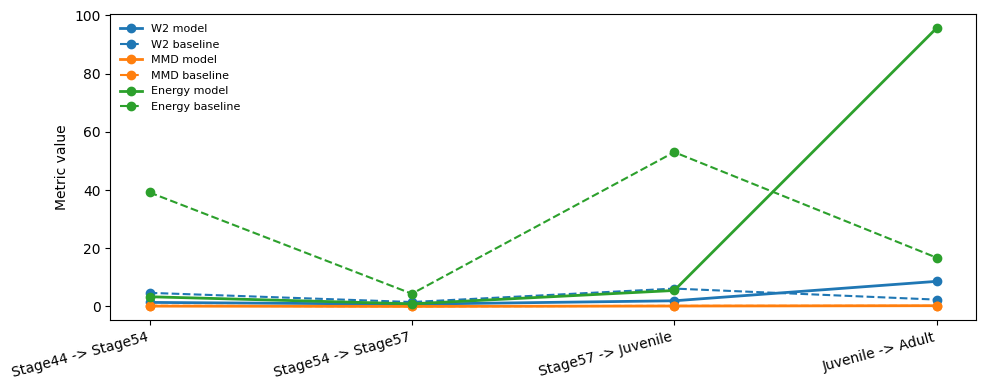

,W2 (model),W2 (baseline),MMD (model),MMD (baseline),Energy (model),Energy (baseline)
transition,,,,,,
Stage44 -> Stage54,1.3904,4.6730,0.1097,0.2457,3.3324,39.1768
Stage54 -> Stage57,0.7760,1.5189,0.0113,0.0274,0.8973,4.3635
Stage57 -> Juvenile,1.9444,6.1394,0.1427,0.2055,5.4882,53.0351
Juvenile -> Adult,8.6229,2.3504,0.2542,0.2069,95.6461,16.7737


In [17]:
metrics = compute_metrics(ns_pred, adata)
metrics

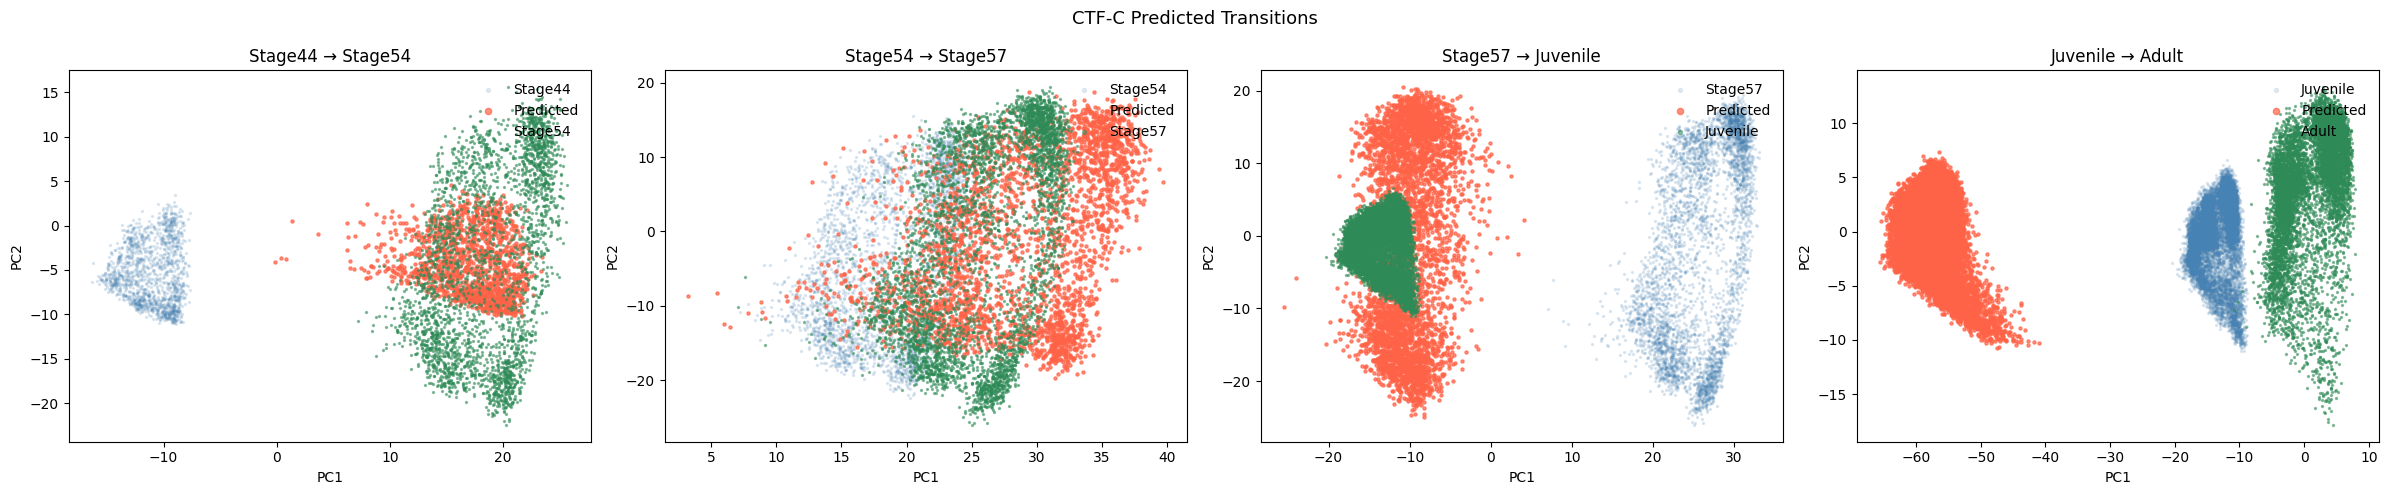

In [18]:
plot_transitions(adata, transitions.items(), ns_pred, title="CTF-C Predicted Transitions")

### IVP

In [19]:
ns_pred = predict_ivp(
    model,
    transitions.items(),
)

Predicting: 100%|██████████| 1/1 [00:02<00:00,  2.09s/it]


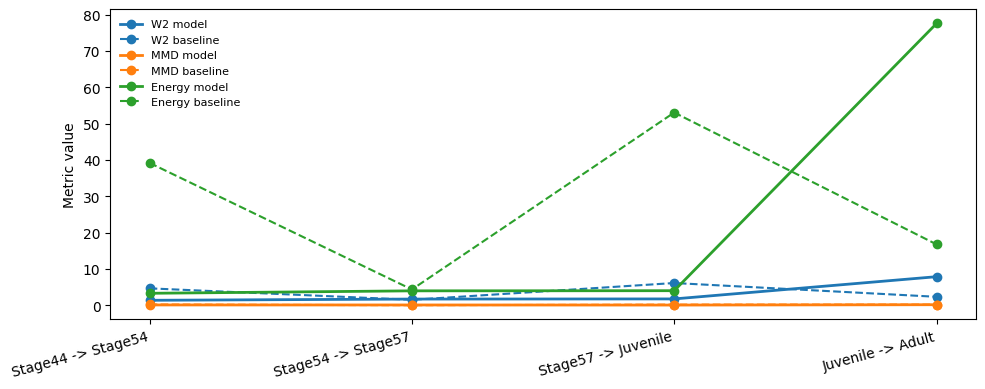

,W2 (model),W2 (baseline),MMD (model),MMD (baseline),Energy (model),Energy (baseline)
transition,,,,,,
Stage44 -> Stage54,1.3880,4.6730,0.1095,0.2457,3.3159,39.1768
Stage54 -> Stage57,1.7272,1.5189,0.1037,0.0274,3.9878,4.3635
Stage57 -> Juvenile,1.7660,6.1394,0.0778,0.2055,4.0269,53.0351
Juvenile -> Adult,7.8805,2.3504,0.1714,0.2069,77.5368,16.7737


In [20]:
metrics = compute_metrics(ns_pred, adata)
metrics

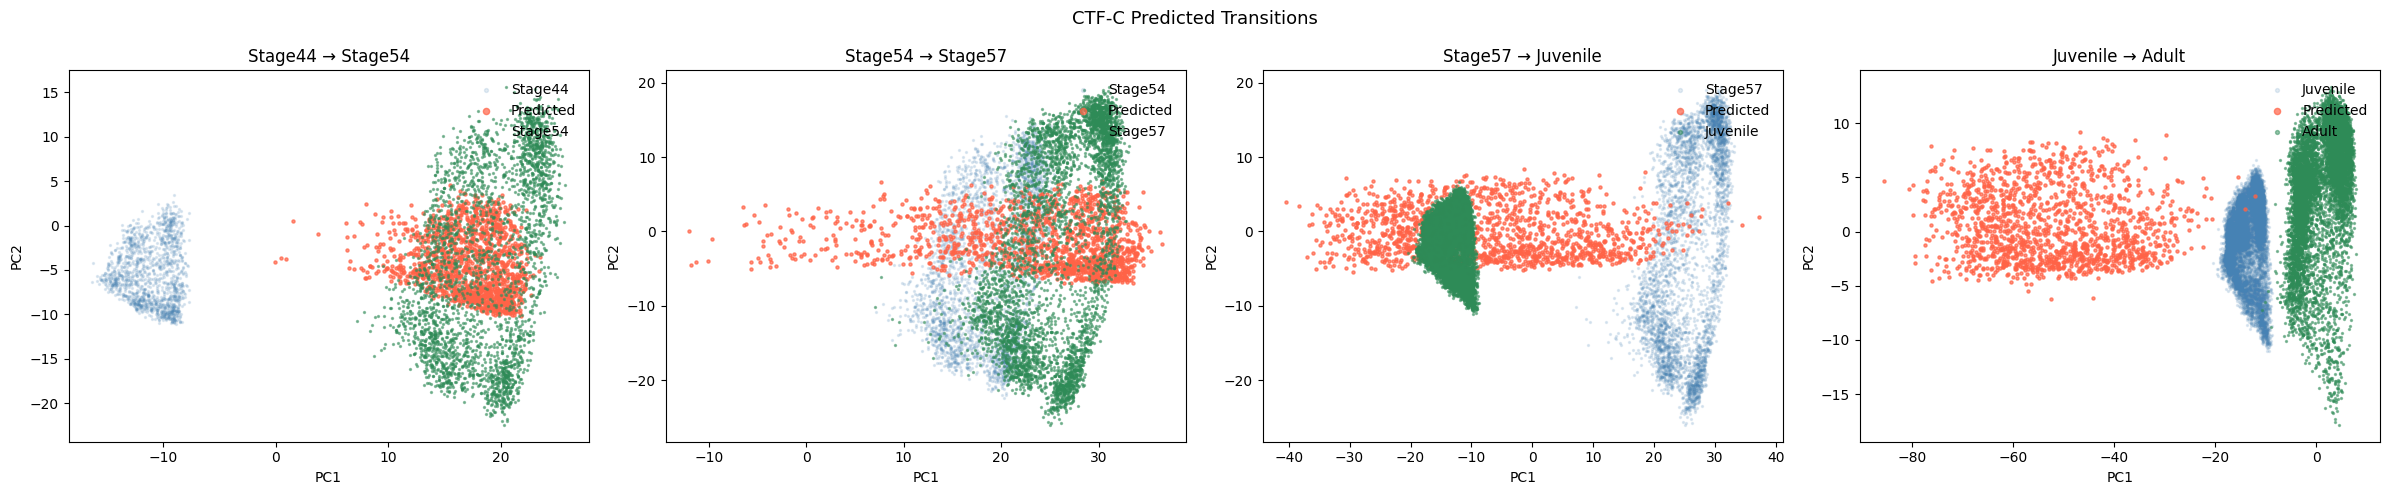

In [21]:
plot_transitions(adata, transitions.items(), ns_pred, title="CTF-C Predicted Transitions")

 ## Intrapolation

In [22]:
ALPHA = 0.5
LAMBDA = 0.4
hidden_dims = (10, 10, 10)
activation = torch.nn.SELU
epoch = 10_000
encode_state = False
encode_time = False
lr = 1e-4
batch_size = 256
probability_path = LinearGaussianProbabilityPath(sigma=0.9, prng=prng)
scale_method = 1.0  # Cost matrix is not scaled in ContextFlow
reg = 0.1
N_EVAL = 1500
solver = "dopri5"
debug_intra = "debug_intra2"

matched_keys = {
    ("Stage44",): ("Stage54",),
    ("Stage54",): ("Stage57",),
    ("Stage57",): ("Adult",),
}

transitions = {
    "Stage44": "Stage54",
    "Stage54": "Stage57",
    "Stage57": "Juvenile",
    "Juvenile": "Adult",
}

t_start_train = [0, 1, 2, 4]

t_start_pred = [0, 1, 2, 3]
t_end_pred = [1, 2, 3, 4]

In [23]:
configure_ot_debug(output_dir=debug_intra, max_steps=10)
model = run(
    MATCHED_KEYS=matched_keys,
    LAMBDA=LAMBDA,
    ALPHA=ALPHA,
    scale_method=scale_method,
    reg=reg,
    hidden_dims=hidden_dims,
    activation=activation,
    epoch=epoch,
    batch_size=batch_size,
    lr=lr,
    probability_path=probability_path,
    encode_state=encode_state,
    encode_time=encode_time,
)

100%|██████████| 3/3 [00:00<00:00, 2927.62it/s]
| loss:8.2949 | step:9999: 100%|██████████| 10000/10000 [07:50<00:00, 21.24it/s]


### Next Step

In [24]:
ns_pred = predict(model, solver=solver, PRED_KEYS=transitions.items(), T_START_PRED=t_start_pred, T_END_PRED=t_end_pred)

Predicting: 100%|██████████| 1/1 [00:20<00:00, 20.93s/it]


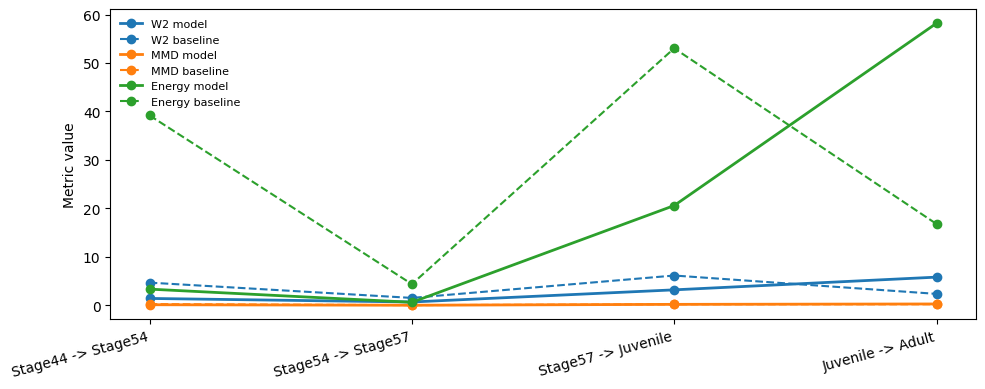

,W2 (model),W2 (baseline),MMD (model),MMD (baseline),Energy (model),Energy (baseline)
transition,,,,,,
Stage44 -> Stage54,1.4094,4.6730,0.1116,0.2457,3.3321,39.1768
Stage54 -> Stage57,0.6765,1.5189,0.0098,0.0274,0.6151,4.3635
Stage57 -> Juvenile,3.1843,6.1394,0.1888,0.2055,20.5829,53.0351
Juvenile -> Adult,5.8090,2.3504,0.2709,0.2069,58.2048,16.7737


In [25]:
metrics = compute_metrics(ns_pred, adata)
metrics

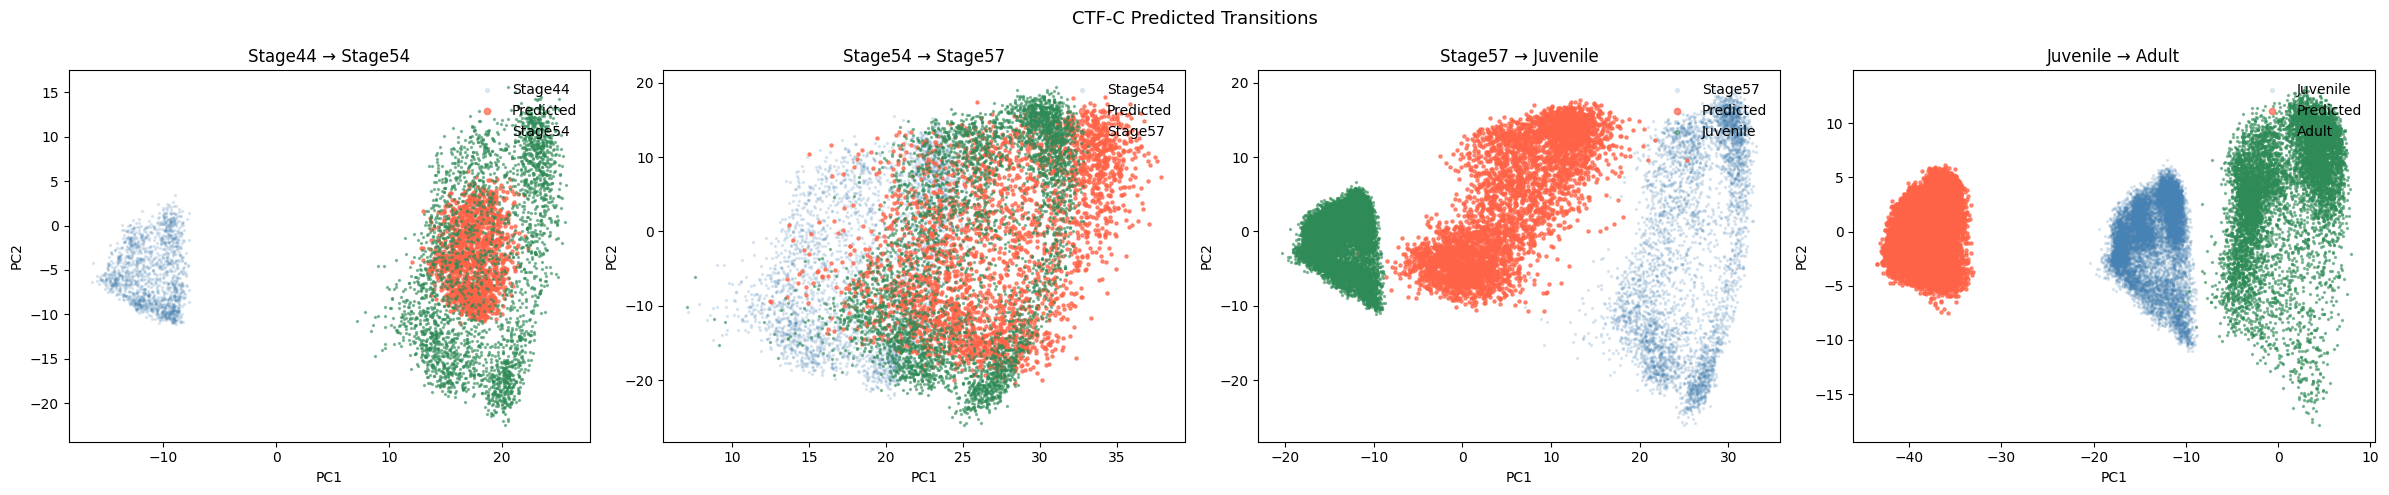

In [26]:
plot_transitions(adata, transitions.items(), ns_pred, title="CTF-C Predicted Transitions")

### IVP

In [27]:
ns_pred = predict_ivp(
    model,
    transitions.items(),
)

Predicting: 100%|██████████| 1/1 [00:00<00:00,  1.11it/s]


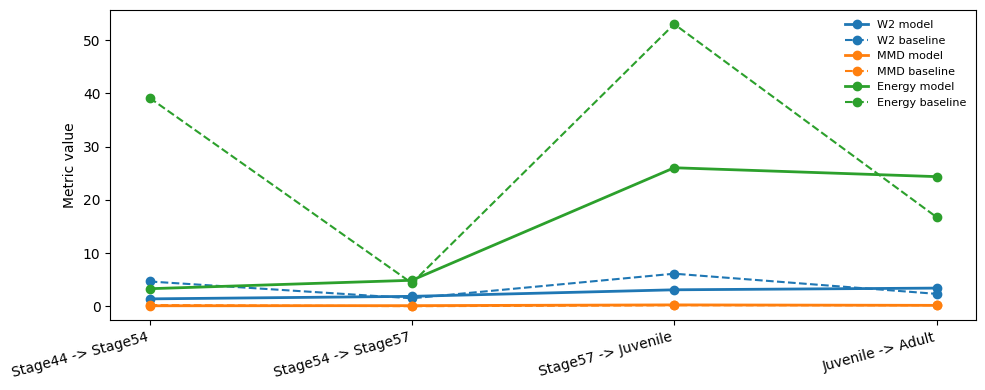

,W2 (model),W2 (baseline),MMD (model),MMD (baseline),Energy (model),Energy (baseline)
transition,,,,,,
Stage44 -> Stage54,1.4075,4.6730,0.1114,0.2457,3.3177,39.1768
Stage54 -> Stage57,1.8826,1.5189,0.1352,0.0274,4.9024,4.3635
Stage57 -> Juvenile,3.1129,6.1394,0.2778,0.2055,26.0441,53.0351
Juvenile -> Adult,3.4323,2.3504,0.1897,0.2069,24.3773,16.7737


In [28]:
metrics = compute_metrics(ns_pred, adata)
metrics

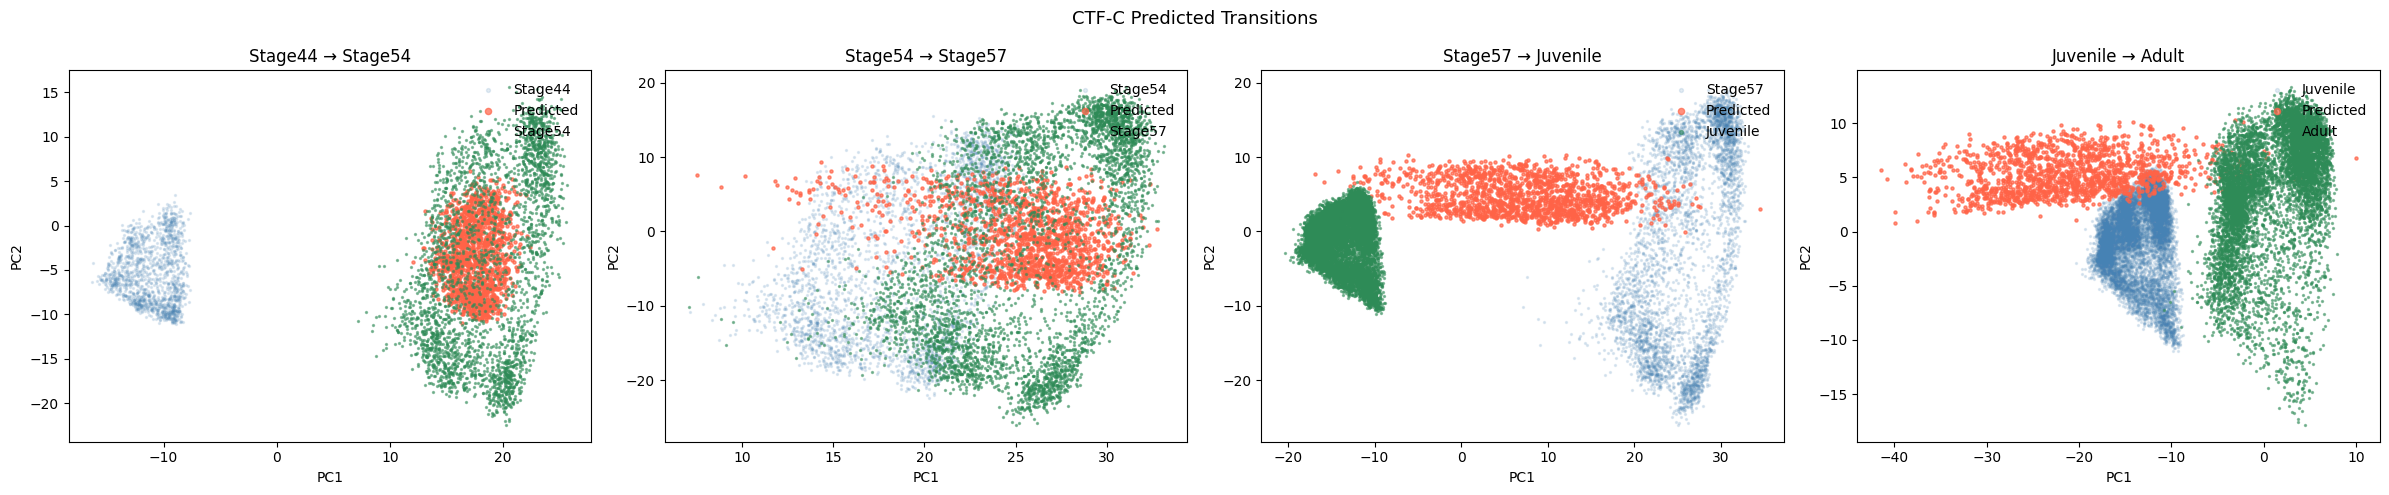

In [29]:
plot_transitions(adata, transitions.items(), ns_pred, title="CTF-C Predicted Transitions")